# 26회차 기출문제

## 문제 1

**Data description**

-   **Invoice_no** : 송장번호

-   **Stock_code** : 제품코드

-   **Stock_category** : 제품 분류

-   **Quantity** : 수량

-   **Invoice_date** : 주문일자

-   **Unit_price** : 단가

-   **Customer_id** : 고객번호

-   **Country** : 국가

#### 데이터 셋:problem1.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [300]:
df = pd.read_csv('./problem1.csv')
print(df.info())
display(df.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35801 entries, 0 to 35800
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    35801 non-null  object 
 1   StockCode    35801 non-null  object 
 2   Description  35801 non-null  object 
 3   Quantity     35776 non-null  float64
 4   InvoiceDate  35801 non-null  object 
 5   UnitPrice    35704 non-null  float64
 6   CustomerID   35801 non-null  float64
 7   Country      35801 non-null  object 
dtypes: float64(3), object(5)
memory usage: 2.2+ MB
None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,563808,22432,WATERING CAN PINK BUNNY,6.0,8/19/2011 11:46,1.95,12626.0,Germany
1,561645,23166,MEDIUM CERAMIC TOP STORAGE JAR,12.0,7/28/2011 15:16,1.25,14911.0,EIRE


1.  **결측치 처리하시오.**

In [301]:
df.isna().sum()[df.isna().sum()>0]

Quantity     25
UnitPrice    97
dtype: int64

In [302]:
df.isna().mean()[df.isna().sum()>0]*100

Quantity     0.069830
UnitPrice    0.270942
dtype: float64

Quantity, UnitPrice 컬럼에서 25, 97개의 결측치가 발견되었다.  
이는 전체 데이터 대비 약 0.06, 0.27%로 아주 적은 비율을 차지하므로 결측치를 제거하더라도 모델학습에 큰 영향을 주지 않는다.(다만 이상치 탐지모델의 경우에는 삭제하지 않는 것이 적절함)  
시간이 충분하다면 각 feature들의 연관성을 식별하여 대푯값으로 치환하거나 knnimputer 등의 머신러닝 기반 보간법을 적용하는 것도 고려할 수 있을 것이다. 

이번 문제에서는 삭제한다. 

In [303]:
df = df.dropna()

2.  **고객 데이터를 활용하여 군집분석을 수행하려고 한다. 군집분석 수행 전에 이상치를 제거하려고 한다. 이상치를 제거하는 방법을 설명하고, 이상치를 제거한 후 이상치가 모두 제거되었다는 통계 자료를 제시하시오.**

사분위수 IQR을 활용하여 상 하단 범위에 속하지 않는 데이터를 이상치로 간주하여 탐색한다.  기타 방법으로는 zscore +-3 표준편차 방식도 있을 것이다.  

우선 이상치 후보군을 탐색 후 각 feature의 경향성을 확인하여 제거여부를 결정한다. 

In [304]:
c_cols = df.select_dtypes('number').columns[:-1]
ds = df[c_cols].describe().T

q1 = ds['25%']
q3 = ds['75%']
iqr = q3 - q1
top = q3 + (1.5*iqr)
down = q1 - (1.5*iqr)

print(f"<<IQR 기준 상하단 이상치 수>>")
for idx in top.index:
    cnt = len(df[(df[idx] > top[idx]) | (df[idx] > down[idx])])
    print(f"- {idx} ({down[idx]} ~ {top[idx]}): {cnt}({cnt/len(df)*100:.2f}%)")

<<IQR 기준 상하단 이상치 수>>
- Quantity (-14.0 ~ 34.0): 35581(99.73%)
- UnitPrice (-2.5 ~ 7.5): 35679(100.00%)


In [305]:
# z-score 기준 

from scipy.stats import zscore

for col in c_cols:
    z_score = np.abs(zscore(df[col]))
    out_p = df[z_score > 3]
    print(f"- {col} z-점수 기준 이상치 수: {len(out_p)} ({len(out_p)/len(df)*100:.2f} %)" )

- Quantity z-점수 기준 이상치 수: 475 (1.33 %)
- UnitPrice z-점수 기준 이상치 수: 41 (0.11 %)


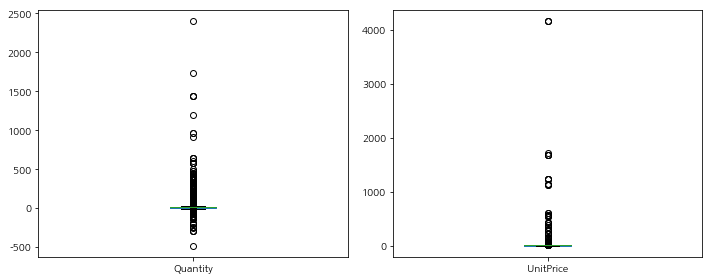

In [306]:
#boxplot 
df[c_cols].plot(kind='box', subplots=True, layout=(1, 2), figsize=(10, 4))
plt.tight_layout()
plt.show()

IQR 기준으로 상당히 많은 비율이 이상치로 탐지되며,  
Z SCORE +-3 표준편차 기준으로는 이상치 비율이 확연히 줄어들었다.  
Z SCORE 기준으로 이상치 후보군을 삭제할 수도 있지만 일반적인 기준을 가지고 해당 데이터를 보았을 때 구매수량의 수는 적을수도 있고, 많을 수도 있다.  
또한 단가 또한 천차만별이므로 통계적인 기준으로 이상치로 확정하여 삭제하는 것은 적절치 않다.  

다만 수량은 0이하일 수 없으므로 해당 값을 삭제하고, 단가 데이터는 삭제하지 않는다.
(0 인 경우는 사은품일 수도 있기 떄문이다.)

In [307]:
print(f"수량 데이터 삭제 전 개수: {len(df)}")
df = df[df['Quantity'] > 0]
print(f"수량 데이터 삭제 후 개수: {len(df)}")

수량 데이터 삭제 전 개수: 35679
수량 데이터 삭제 후 개수: 34688


991개의 데이터를 삭제하였다. 원본 데이터의 약 2.8%이다.  

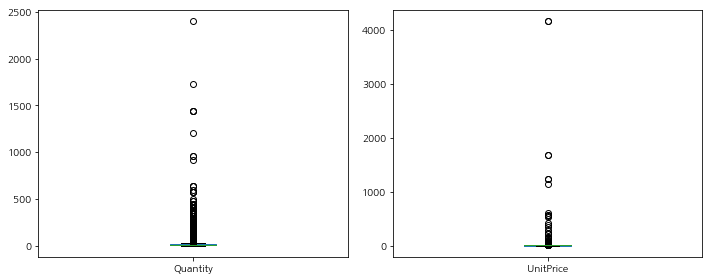

In [308]:
df[c_cols].plot(kind='box', subplots=True, layout=(1, 2), figsize=(10, 4))
plt.tight_layout()
plt.show()

3.  **kmeans 또는 DBSCAN 등의 기법을 활용하여 군집을 생성하시오.**

두 군집모델은 비지도학습 모델이다. 따라서 군집분류를 위한 특징정보가 필요하므로  
기존 데이터에서 파생변수를 생성한다.  

- kmeans: k개의 중심을 초기화한 후 각 데이터를 가장 가까운 중심에 할당하고 중심좌표를 반복적으로 갱신, 구형군집에 적합하며 사전 군집수 k 지정이 필요
- DBScan: 밀도기반 군집모델로 비구형 데이터에서도 사용이 가능하며, 노이즈 자동제거 효과가 있다. 하지만 하이퍼파라미터(거리, 최소샘플수) 설정에 민감하다.  

해당 문제에서는 보다 구현 및 해석이 수월한 kmeans 클러스터링 기법을 활용한다.    
(거리기반 모델이므로 스케일링 수행)  
파생변수 생성 후 실루엣 점수 평가를 통해 군집수 k 를 지정 후 군집을 생성한다. 

결국 각 고객별 특징을 탐지하여 비슷한 특성 간 군집을 형성해야 하기때문에 다음의 파생변수를 생성한다.  

앞서 고객별 수량, 단가의 범위가 매우 컸기 때문에 이 변동을 완화하여 반영하기 위해  
고객별 수량, 단가의 중앙값을 파생변수로 활용한다. 

In [309]:
df_c = df.copy()
# 고객별 구매수량, 구매단가, 국가코드
train= df_c.groupby('CustomerID')[['Quantity', 'UnitPrice']].median()

train.head()

,Quantity,UnitPrice
CustomerID,,
12354.0,6.0,2.95
12356.0,24.0,1.25
12357.0,16.0,2.10
12361.0,10.0,1.95
12362.0,6.0,2.55


In [310]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
train = pd.DataFrame(sc.fit_transform(train), columns=train.columns, 
                     index=train.index)
train.head()

,Quantity,UnitPrice
CustomerID,,
12354.0,-0.482682,0.346743
12356.0,1.178568,-0.599484
12357.0,0.440235,-0.126370
12361.0,-0.113516,-0.209861
12362.0,-0.482682,0.124101


<적정한 군집수 구하기>


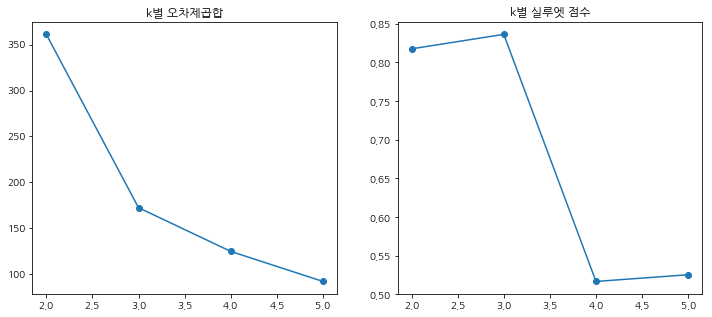

In [311]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 적정한 군집수 구하기: 오차제곱합에서 엘보(떨어지는구간) 찾음
print(f"<적정한 군집수 구하기>")
e = [] #오차제곱합
ss = [] #실루엣 점수

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k).fit(train)
    e.append(kmeans.inertia_)
    s = silhouette_score(train, kmeans.labels_)
    ss.append(s)
ax[0].plot(list(range(2, 6)), e, marker='o')
ax[1].plot(list(range(2, 6)), ss, marker='o')
ax[0].set_title('k별 오차제곱합')
ax[1].set_title('k별 실루엣 점수')
plt.show()

오차제곱합에서 K=3지점에서 엘보우 포인트(오차제곱합이 급격히 떨어지는 지점) 식별 및  실루엣 점수 또한 해당 지점에서 가장 높았다.  
따라서 k=3으로 지정 후 비지도학습을 수행한다.

In [312]:
from collections import Counter
k = 3
model = KMeans(n_clusters=k, random_state=42)
dist = model.fit_transform(train) #각 열의 각 클러스터 중심과의 거리
rs = model.labels_ #각 데이터 군집반환

print(f"클러스터 구성: {Counter(rs)}")
center = pd.DataFrame(model.cluster_centers_, 
                      columns = train.columns, 
                      index = ['cluster'+ str(i) for i in range(k)]
                     )

print(f"클러스터 중심")
display(center)


클러스터 구성: Counter({0: 272, 1: 9, 2: 6})
클러스터 중심


,Quantity,UnitPrice
cluster0,-0.145241,-0.133400
cluster1,4.772817,0.349526
cluster2,-0.574974,5.523160


k=3로 클러스터링 한 결과이다. 클러스터 0에 대다수의 고객이 위치하고, 
2, 3에는 일부 고객만 위치하고 있다.   
위의 표는 각 클러스터 중심과 각 컬럼 데이터의 거리 평균이다.  

4.  **생성된 군집에 대하여 군집성능지표를 산출하고, 군집간 차이와 특성을 분석한 결과를 제시하시오.**

In [313]:
# 실루엣 점수
score = silhouette_score(train, model.labels_)

print(f"실루엣 점수: {score}")

실루엣 점수: 0.8359985113253072


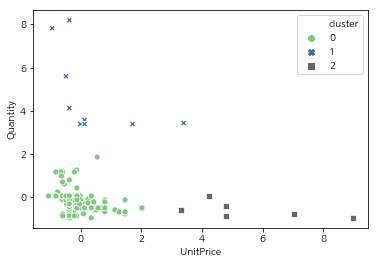

In [314]:
train['cluster'] = rs

sns.scatterplot(data=train, x='UnitPrice', y='Quantity', hue='cluster', 
               style='cluster', palette='Accent')
plt.show()

실루엣 점수로 군집 분류성능을 평가한다.  
실루엣 점수(계수)는 -1~1사이의 값을 가지고 있으며, 1에 가까울 수록 좋은 성능이다.  
실루엣 점수: 0.83599851132530721로 매우 우수한 분류성능을 보임을 알 수 있다.   

산점도 상에서도 3개의 클러스터 경계가 명확함을 알 수 있다. 

<<연속형 변수 통계량 및 boxplot>>


,count,mean,std,min,25%,50%,75%,max
Quantity,287.0,7.891481e-17,1.001747,-0.944141,-0.482682,-0.113516,0.071068,8.192736
UnitPrice,287.0,2.429338e-16,1.001747,-1.061465,-0.376842,-0.209861,0.044785,8.974105
cluster,287.0,7.317073e-02,0.331680,0.000000,0.000000,0.000000,0.000000,2.000000


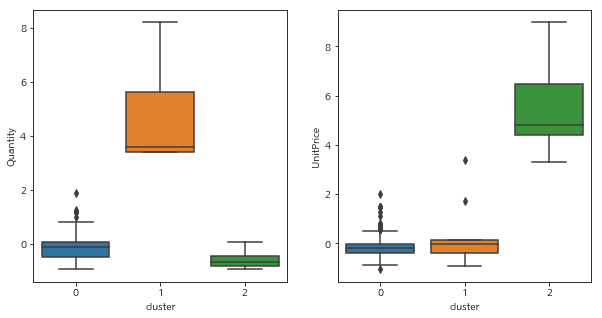

In [315]:
print('<<연속형 변수 통계량 및 boxplot>>')
display(train.describe().T)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for i, col in enumerate(n_cols):
    sns.boxplot(data=train, x='cluster', y=col, ax=ax[i])
plt.show()

- 클러스터0: 구매수량이 낮으며, 유닛 단가 또한 낮은 편이다.(구매력이 낮은 고객)
- 클러스터1: 비교적 많은 구매수량, 낮은 단가(저렴한 물품을 많이 구매하는 고객)
- 클러스터2: 구매수량 낮음, 구매단가 높음(고가의 물품을 적게 구매하는 고객)

5.  **군집별로 대표적인 추천상품을 구성하고, 군집별 추천 상품을 제시하고, 타군집과의 추천상품 차이를 설명하시오.**

In [316]:
train = train.reset_index()
data = pd.merge(df, train[['CustomerID', 'cluster']], on='CustomerID', how='left')

In [317]:
for c in range(3):
    sub = data[data['cluster'] == c]
    top_code = sub['StockCode'].value_counts().head(5).index
    top_item = sub['Description'].value_counts().head(5)
    rss = pd.DataFrame(top_item)
    rss['중앙값 단가'] = sub[(sub['StockCode'].isin(top_code))].groupby('StockCode')['UnitPrice'].median().reindex(top_code).values
    rss['중앙값 구매갯수'] = sub[sub['StockCode'].isin(top_code)].groupby('StockCode')['Quantity'].median().reindex(top_code).values
    rss.drop('Description', axis=1, inplace=True)
    print(f"구매물품: {top_item.index.tolist()}")
    print(f"-- {c} 클러스터 Top5 item --")
    display(rss)

구매물품: ['POSTAGE', 'ROUND SNACK BOXES SET OF4 WOODLAND ', 'REGENCY CAKESTAND 3 TIER', 'PLASTERS IN TIN WOODLAND ANIMALS', 'PLASTERS IN TIN CIRCUS PARADE ']
-- 0 클러스터 Top5 item --


,중앙값 단가,중앙값 구매갯수
POSTAGE,18.00,2.0
ROUND SNACK BOXES SET OF4 WOODLAND,2.95,6.0
REGENCY CAKESTAND 3 TIER,12.75,4.0
PLASTERS IN TIN WOODLAND ANIMALS,1.65,12.0
PLASTERS IN TIN CIRCUS PARADE,1.65,12.0


구매물품: ['POSTAGE', 'SPACEBOY LUNCH BOX ', 'ROUND SNACK BOXES SET OF4 WOODLAND ', 'DOLLY GIRL LUNCH BOX', 'ROUND SNACK BOXES SET OF 4 FRUITS ']
-- 1 클러스터 Top5 item --


,중앙값 단가,중앙값 구매갯수
POSTAGE,15.00,2.0
SPACEBOY LUNCH BOX,1.65,128.0
ROUND SNACK BOXES SET OF4 WOODLAND,2.55,96.0
DOLLY GIRL LUNCH BOX,1.65,160.0
ROUND SNACK BOXES SET OF 4 FRUITS,0.72,100.0


구매물품: ['POSTAGE', 'BREAD BIN DINER STYLE RED ', 'BREAD BIN DINER STYLE IVORY', 'GUMBALL COAT RACK', 'IVORY KITCHEN SCALES']
-- 2 클러스터 Top5 item --


,중앙값 단가,중앙값 구매갯수
POSTAGE,15.00,2.0
BREAD BIN DINER STYLE RED,14.95,4.0
BREAD BIN DINER STYLE IVORY,14.95,4.0
GUMBALL COAT RACK,8.50,2.0
IVORY KITCHEN SCALES,2.55,6.0


- 클러스터 0: 
'POSTAGE', 'ROUND SNACK BOXES SET OF4 WOODLAND ', 'REGENCY CAKESTAND 3 TIER', 'PLASTERS IN TIN WOODLAND ANIMALS', 'PLASTERS IN TIN CIRCUS PARADE '

- 클러스터 1: 
'POSTAGE', 'SPACEBOY LUNCH BOX ', 'ROUND SNACK BOXES SET OF4 WOODLAND ', 'DOLLY GIRL LUNCH BOX', 'ROUND SNACK BOXES SET OF 4 FRUITS '

- 클러스터 2: 
'POSTAGE', 'BREAD BIN DINER STYLE RED ', 'BREAD BIN DINER STYLE IVORY', 'GUMBALL COAT RACK', 'IVORY KITCHEN SCALES'

각 클러스터의 Top 5 구매물품을 출력하였다.  

세 클러스터에서 공통적으로 우표(POSTAGE)를 가장 많이 구매하였다. 
다만 4번 문제에서 분석한 것처럼 0클러스터는 저렴한 단가의 물품을 2~12 사이러 적게 구매하였으며, 

1클러스터는 단가가 저렴한 물품을(완구 혹은 간식으로 추정됨) 96~160개 가량으로 대량으로 구매한 것을 알 수 있다.(도매업자로 추정됨)  

2클러스터는 인테리어 물품으로 추정되는 단가가 8~15가량의 물품을 적게 구매한 것을 알 수 있다.

6.  **KNN을 활용하여 고객별 근접이웃분석을 수행하고 상품추천을 수행하는 방법을 기술하고, 구현하시오.**

최근접 이웃법을 적용하여 클러스터 2에 속하는 "13811" 고객의 최근접 이웃 3개를 구하고한다.(거리에 민감한 모델이므로 스케일링을 적용)  
이후 이웃의 주요구매물품(top5)을 선정하여 해당 고객에게 추천한다.

고객별 구매 행동을 벡터화한 뒤 K-최근접 이웃(KNN) 알고리즘으로 유사 고객을 찾아, 이들의 구매 이력을 활용해 상품을 추천하는 방식  
1. 기준이 되는 고객 선정
2. 고객 × 상품 매트릭스(희소 행렬)
3. knn 모델 학습(k=3)
4. 특정 고객의 최근접 이웃 3명 추출
5. 추천목록 생성
6. 이웃들이 많이 구매했지만 대상 고객이 아직 구매하지 않은 상품 추천

In [323]:
from sklearn.neighbors import NearestNeighbors

#피처행렬 만들기
train2 = train.drop('cluster', axis=1).reset_index(drop=False)
feat = train2.values # value형태의 feature를 반드시 만들어야 함

# 1) NearestNeighbors 모델 적합
# 자기 자신을 포함하므로 n_neighbors=k+1 로 지정
model = NearestNeighbors(n_neighbors=4, algorithm='auto').fit(train)

# 2) 대상 고객(인덱스)
target_idx = train2.index[train2['CustomerID'] == 13811][0]
target_vector = feat[target_idx].reshape(1, -1)

# 3) 최근접 이웃 거리 및 인덱스 조회
dist, indices = model.kneighbors(target_vector)

# 4) 자기 자신(첫 번째)을 제외하고 k=3 이웃 추출
neighbor_idxs = indices[0][1:4]
neighbor_distances = dist[0][1:4]

# 5) 결과 출력
neighbors = train2.loc[neighbor_idxs, ['CustomerID', 'Quantity', 'UnitPrice']].copy()
neighbors['distance'] = neighbor_distances

print("CustomerID 13811.0 의 k=3 최근접 이웃:")
print(neighbors)

CustomerID 13811.0 의 k=3 최근접 이웃:
   CustomerID  Quantity  UnitPrice      distance
1     12356.0  1.178568  -0.599484  18349.661246
2     12357.0  0.440235  -0.126370  18350.875404
3     12361.0 -0.113516  -0.209861  18353.926325


KNN 을 적용하여 최근접이웃 3개를 구하였다. (고객번호: 12497, 14646, 12678)  

해당 고객의 빈발 구매물품을 고객에게 추천한다. 

In [337]:
for c in [13811, 12356, 12357, 12361]:
    sub = data[data['CustomerID'] == c]
    top_code = sub['StockCode'].value_counts().head(5).index
    top_item = sub['Description'].value_counts().head(5)
    rss = pd.DataFrame(top_item)
    rss['단가'] = sub[(sub['StockCode'].isin(top_code))].groupby('StockCode')['UnitPrice'].median().reindex(top_code).values
    rss['구매갯수'] = sub[sub['StockCode'].isin(top_code)].groupby('StockCode')['Quantity'].sum().reindex(top_code).values
    rss.drop('Description', axis=1, inplace=True)
    print(f"구매물품: {top_item.index.tolist()}")
    print(f"-- {c} 고객 Top5 item --")
    display(rss)

구매물품: ['RECYCLED ACAPULCO MAT TURQUOISE', 'RECYCLED ACAPULCO MAT BLUE', 'RECYCLED ACAPULCO MAT GREEN', 'RECYCLED ACAPULCO MAT RED', 'RECYCLED ACAPULCO MAT PINK']
-- 13811 고객 Top5 item --


,단가,구매갯수
RECYCLED ACAPULCO MAT TURQUOISE,8.25,12.0
RECYCLED ACAPULCO MAT BLUE,8.25,13.0
RECYCLED ACAPULCO MAT GREEN,18.00,4.0
RECYCLED ACAPULCO MAT RED,8.25,13.0
RECYCLED ACAPULCO MAT PINK,8.25,15.0


구매물품: ['RED RETROSPOT CAKE STAND', 'REGENCY CAKESTAND 3 TIER', '60 TEATIME FAIRY CAKE CASES', 'SET OF 3 HEART COOKIE CUTTERS', 'FAIRY CAKES NOTEBOOK A6 SIZE']
-- 12356 고객 Top5 item --


,단가,구매갯수
RED RETROSPOT CAKE STAND,10.950,11.0
REGENCY CAKESTAND 3 TIER,12.750,22.0
60 TEATIME FAIRY CAKE CASES,0.485,168.0
SET OF 3 HEART COOKIE CUTTERS,1.250,51.0
FAIRY CAKES NOTEBOOK A6 SIZE,6.950,12.0


구매물품: ['BANQUET BIRTHDAY  CARD  ', 'ALARM CLOCK BAKELIKE RED ', 'RED RETROSPOT MINI CASES', 'PINK DOUGHNUT TRINKET POT ', 'SPACEBOY BIRTHDAY CARD']
-- 12357 고객 Top5 item --


,단가,구매갯수
BANQUET BIRTHDAY CARD,1.85,72.0
ALARM CLOCK BAKELIKE RED,12.75,8.0
RED RETROSPOT MINI CASES,2.95,12.0
PINK DOUGHNUT TRINKET POT,1.95,12.0
SPACEBOY BIRTHDAY CARD,1.25,12.0


구매물품: ['PLASTERS IN TIN STRONGMAN', 'ROUND SNACK BOXES SET OF4 WOODLAND ', 'CIRCUS PARADE LUNCH BOX ', 'SPACEBOY LUNCH BOX ', 'ROUND SNACK BOXES SET OF 4 FRUITS ']
-- 12361 고객 Top5 item --


,단가,구매갯수
PLASTERS IN TIN STRONGMAN,1.95,12.0
ROUND SNACK BOXES SET OF4 WOODLAND,1.65,12.0
CIRCUS PARADE LUNCH BOX,1.95,12.0
SPACEBOY LUNCH BOX,1.65,10.0
ROUND SNACK BOXES SET OF 4 FRUITS,1.65,10.0


13811 고객의 빈발 구매물품을 살펴보니, "재활용" , "매트"(인테리어 물품) 물품을 많이 구매한 것을 알 수 있다. 

추천된 이웃의 빈발구매물품 중 해당고객이 구매하지 않은 "인테리어" 카테고리 항목(예: RED RETROSPOT CAKE STAND)을  
구매추천한다. 


## 문제 2 (25회 기출)

**Data description**

우리나라에 입국한 관광객 수에 관한 데이터입니다.

-   train : 1981.1 \~ 1991.12
-   test : 1992.1 \~ 1992.12
#### 데이터 셋:problem2.csv

1.  **데이터를 탐색하시오.**

In [353]:
df2 = pd.read_csv('./problem2.csv')
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   144 non-null    object 
 1   value   140 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB
None


In [354]:
df2['index'] = pd.to_datetime(df2['index'] ).dt.strftime('%Y-%m')
df2.set_index('index', inplace=True)

In [358]:
df2[df2['value'].isna()==True]

,value
index,
1981-10,NaN
1981-11,NaN
1981-12,NaN
1982-01,NaN


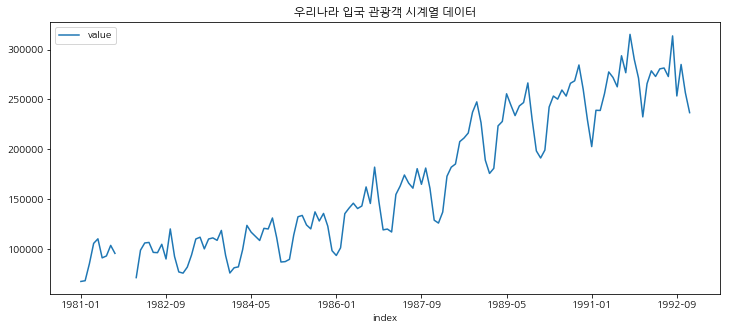

In [356]:
df2.plot(figsize = (12, 5))
plt.title('우리나라 입국 관광객 시계열 데이터')
plt.show()

데이터 index는 실제로는 날짜 데이터이다. 추후 데이터 분석을 용이하게 하기 위해 날짜(년-월)형으로 변환 후 인덱스 지정해 주었다.  
데이터는 1981년 10월부터 82년 1월까지 연속적으로 4달 간 결측치가 관측된다.  

plot을 살펴보면 12개월 단위로 계절성 추세가 관찰되며, 년도가 지날수록 분산이 증가하는 것을 확인할 수 있다.
(분산 변동 완화를 위해 boxcox 변환을 고려할 수 있음)  

2.  **결측치 확인 및 결측치를 대치하시오.**

3.  **계절성을 포함하는 시계열 모델을 구축하고 정확도 측면에서 제시하시오.**

계절차분을 통해 계절성이 제거된 것 확인(stl은 조금이라도 계절성이 남아있으면 표시됨)  
차분 이후 데이터(origin)을 봐야 함

4.  **업무에 적용할 수 있는지, 판단근거와 함께 서술하시오.**

test set을 예측하여 실제 데이터와 예측정도를 비교해본다.

test set 기준으로 실제값과 예측값을 비교해보았다.(boxcox 역변환)  
그래프를 보면 test set은 train set의 패턴까지는 잘 학습한 것으로 보인다.    
하지만 실제값과 예측값은 다소 차이가 있음을 볼 수 있다.

다음으로 두 평가지표를 기준으로 판단해본다.  
- MAPE(Mean Absolute Percentage Error, 평균 절대 비율 오차)는 모델의 예측 오차를 실제 값에 대한 상대적인 비율(%)로 나타낸 지표로  
  작을수록 좋은 성능을 낸다. 일반적으로 MAPE 값은 0에 가까울수록 좋으며, 10% 미만은 매우 좋은 예측, 20-50%는 보통,  
  100% 이상은 예측이 부정확하다고 판단
- MASE: 시계열 예측의 성능을 평가하는 지표로, 예측 오차의 평균 절대값을 학습 시계열의 1차 차분 절대값 평균(naive 예측 오차)으로  
  나눈 값임. 데이터의 단위에 상관없이 상대적인 예측 정확도를 쉽게 비교할 수 있도록 해 주는 지표이며 해석이 간단하고 쉬움
  - 1보다 작으면: 예측 모델이 naive 예측보다 성능이 좋음
  - 1보다 크면: 예측모델이 naive 예측보다 성능이 낮음

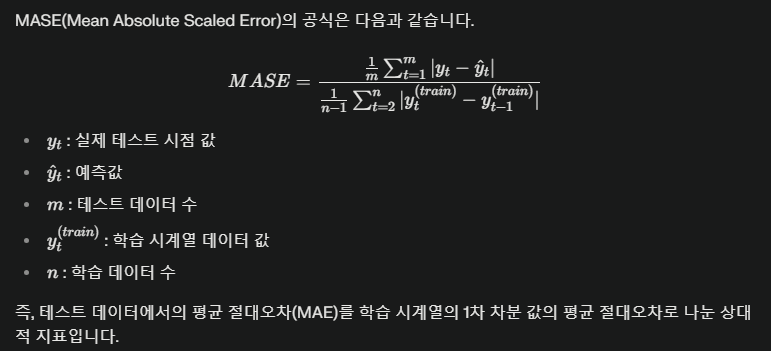

- MAPE가 1.245라는 것은 예측 성능이 매우 낮으며, 예측 오차가 실제값 대비 평균 124.5%에 달해 개선이 필요함을 나타냄  
- MASE가 1.738이라는 것은 예측 모델이 naive 예측보다 성능이 낮음을 나타냄

따라서 해당모델을 업무에 적용하기는 적절치 않으며, LSTM, GRU, Prophet 등 다른 모델을 고려하는 것이 바람직하다.  
특히, 데이터에 비선형성이나 외부요인이 영향을 줄 수 있다면 딥러닝 기반의 모델이 더 적절할 것이다.

## 문제 3(변형 문제)

**별도의 데이터 없음**

돈돈이는 사회학 연구소에서 연구원으로 일하고 있습니다. 그는 직업 만족도가 사람들의 수입 수준에 따라 어떻게 달라지는지 궁금했습니다. 이를 위해 도시에서 일하는 96명의 사람들을 대상으로 설문조사를 진행했습니다. 설문조사에서는 응답자들의 수입과 직업 만족도에 대해 물어보았고, 그 결과는 다음과 같았습니다.


| 수입\직업만족도   | **VD (매우 불만족)** | **LD (조금 불만족)** | **MS (조금 만족)** | **VS (매우 만족)** |
|------------------|---------------------|----------------------|--------------------|---------------------|
| **<15,000**      |          1          |          3           |        10          |         6           |
| **15,000-25,000**|          2          |          3           |        10          |         7           |
| **25,000-40,000**|          1          |          6           |        14          |        12           |
| **>40,000**      |          0          |          1           |         9          |        11           |


1.  **수입 수준과 직업 만족도 간의 순위 관계를 파악하기 위해 Goodman and Kruskal의 Gamma 계수를 계산하시오.**

gamma = (P-Q) / (P+Q)   
- P: 순위가 일치하는 쌍의 수
- Q: 순위가 불일치하는 쌍의 수

P: 두 쌍 비교 시 수입도 증가하고, 직업만족도도 증가하는 경우 쌍의 개수((1,1) 과 (2, 2) 쌍 비교)  
Q: 두 쌍 비교 시 수입은 증가하나, 직업만족도는 감소하는 경우 쌍의 개수((1, 2)와 (2, 1) 쌍 비교)  

**<해석>**  

- 범위: -1 <= G <= 1
- G = 1: 완전한 순위 일치(강한 양의 상관관계)
- G = -1: 완전한 순위 불일치(강한 음의 상관관계)
- G = 0: 순위간 무상관(동점은 계산에서 제외)

In [4]:
data = {
    "수입": ["<15,000", "15,000-25,000", "25,000-40,000", ">40,000"],
    "VD": [1, 2, 1, 0],      # 매우 불만족
    "LD": [3, 3, 6, 1],      # 조금 불만족
    "MS": [10, 10, 14, 9],   # 조금 만족
    "VS": [6, 7, 12, 11]     # 매우 만족
}
df = pd.DataFrame(data)
df = df.set_index('수입') #반드시 인덱스 설정해야 함

In [6]:
from itertools import product

# 감마계수 계산
P = 0 #순위일치 쌍 수 초기화
Q = 0 #순위불일치쌍 수 초기화

# 순위 일치 쌍 수 계산
for (i1, j1), (i2, j2) in product(np.ndindex(df.shape), repeat=2):
    if (i1 < i2) & (j1 < j2): #수입도 증가하고 작업만족도도 증가
        P += df.iloc[i1, j1] * df.iloc[i2, j2]
    elif (i1 < i2) & (j1 > j2): #순위 불일치(수입기준)
        Q += df.iloc[i1, j1] * df.iloc[i2, j2]
        
#gamma 계산
g = (P-Q)/(P+Q)

print(f"순위일치쌍 수: {P} / 순위불일차쌍 수: {Q}")
print(f"Goodman and Kruskal의 Gamma 계수: {g}")

순위일치쌍 수: 1331 / 순위불일차쌍 수: 849
Goodman and Kruskal의 Gamma 계수: 0.22110091743119267


2. 유의수준 5% 하에서 가설검정에 대한 검정통계량 계산(소숫점 셋째까지 표시), 연구가설의 채택여부를 결정

<가설설정>  

- 귀무가설: 두 변수 간 순위상관관계가 없음
- 대립가설: 두 변수 간 순위상관관계가 있음

In [8]:
from scipy.stats import norm

z = (P-Q)/np.sqrt(P+Q)
p = (1-norm.cdf(abs(z)))*2 
print(f"검정통계량: {z:.3f} / p-value: {p:.3f}")

검정통계량: -29.138 / p-value: 0.000


유의수준 5% 하에서 양측검정 p-value가 0으로 귀무가설을 기각한다.  
따라서 두 변수 간 순위상관관계가 있음은 통계적으로 유의하다. 


## 문제 4

**별도의 데이터 없음**

슬통 전구회사는 자사의 제품 생산 라인에서 최근 불량률이 급증했다는 내부 보고서를 받았습니다. 초기 보고서에 따르면 불량률이 약 9%에 달한다고 합니다. 회사의 경영진은 이를 확인하기 위해 독립적인 품질 검사팀에 조사를 의뢰하였습니다. 검사팀은 신뢰도 95%로 불량률을 확인하기 위해 필요한 표본 크기를 계산하고자 합니다. 오차한계가 3% 내외로 허용된다면, 검사팀은 최소 몇 개의 제품을 표본으로 선택해야 하는지 계산하시오.



## 문제 5(변형 문제)

**별도의 데이터 없음**

돈돈이는 사회학을 공부하는 대학생으로, 학력 수준에 따라 사람들이 어떤 종교적 신념을 가지고 있는지 궁금해졌습니다. 이를 알아보기 위해, 도시에서 일하는 2726명의 사람들을 대상으로 설문조사를 진행했습니다. 설문조사 응답 결과를 정리한 자료는 다음과 같습니다.

| 학위\\종교적 믿음 | 원리주의자 | 중도 | 원칙주의자 |
|-------------------|------------|------|------------|
| 고졸              | 178        | 138  | 108        |
| 전문대졸          | 570        | 648  | 442        |
| 대졸              | 138        | 252  | 252        |



In [14]:
df = pd.DataFrame([[178, 138, 108], 
                  [570, 648, 442], 
                  [138, 252, 252]], 
                 index=['고졸', '전문대졸', '대졸'], 
                 columns = ['원리주의자', '중도', '원칙주의자'])
display(df)

,원리주의자,중도,원칙주의자
고졸,178,138,108
전문대졸,570,648,442
대졸,138,252,252


1.  **5% 유의수준에서 가설 검증에 대한 검정통계량을 계산하시오. (단, 반올림하여 소수점 셋째 자리까지 표시하시오.) 연구가설의 채택여부를 결정하시오.**.

한 모집단 데이터이며, 3개의 그룹을 가진 각 명목변수-명목변수 간 연관성 여부를 검정하는   
문제이므로 카이제곱 독립성 검정을 실시한다.  

유의수준 5% 하에서 다음과 같은 가설을 수립하고 검정실시한다.  

<가설설정>  
- 귀무가설: 학력수준과 종교적 믿음은 독립이다. 
- 대립가설: 적어도 한 그룹의 학력수준과 종교적 믿음은 연관성이 있다. 

In [15]:
from scipy.stats.contingency import chi2_contingency

stat, p, ddof, expected = chi2_contingency(df)

print(f"카이제곱 검정통계량: {stat:.3f}")
print(f"유의수준 5% 하 p-value: {p:.3f}")

카이제곱 검정통계량: 69.157
유의수준 5% 하 p-value: 0.000


유의수준 5% 하 p-value: 0.743이므로 0.05보다 충분히 커서 귀무가설을 기각할 수 없다.  
따라서 학력수준과 종교적 믿음은 독립이다.

2.  **검정 결과에 대한 잔차분석을 수행하고, 해석하시오.**

In [18]:
s_expected = (df-expected)/np.sqrt(expected) #표준화잔차
rs = pd.DataFrame(s_expected, index=df.index, columns=df.columns)
display(rs)
display(np.abs(rs)>2)

,원리주의자,중도,원칙주의자
고졸,3.423775,-1.845523,-1.499038
전문대졸,1.311771,0.632781,-2.098646
대졸,-4.891737,0.482291,4.592852


,원리주의자,중도,원칙주의자
고졸,True,False,False
전문대졸,False,False,True
대졸,True,False,True


카이제곱 독립성 검정결과의 잔차분석을 시행한다.  
펴준화 편차를 사용하면 빠른 유의성 확인이 가능하므로 변환한다.  
표준화 편차는 절대값이 2 이상이면 통계적으로 유의하므로 해당 조건에 해당하는 잔차를 확인한다.  

고졸인 경우 원리주의자인 경향이 있으며, 대졸인 경우 원칙주의자인 경향이 크고,  
원리주의자가 아닌 경향이 크다.  
전문대졸의 경우 원칙주의자가 아닌 경향이 크며, 유의하지는 않지만 원리주의자에 가깝다.  

따라서 저학력일수록 원리주의자인 경향이 있으며, 학력이 높아질수록 원칙주의자인 경향이 있다고 하겠다. 



## 문제 6

슬통 초등학교에서는 학생들의 건강 관리를 위해 일부 학생들의 혈압을 측정하였습니다. 총 25명의 학생 중 남학생은 16명, 여학생은 9명이었습니다. 학교 건강 관리팀은 남학생과 여학생 사이에 평균 혈압이 차이가 있는지 궁금해하였고, 이를 확인하기 위해 5%의 유의수준에서 검정하려 합니다. (단, 남녀 학생의 혈압이 정규분포를 따르며, 두 집단의 분산이 동일하다고 가정합니다.)

#### 데이터 셋:problem6.csv

In [19]:
df = pd.read_csv('problem6.csv').set_index('No.')
df.head()

,남학생,여학생
No.,,
1,124.97,114.87
2,118.62,128.14
3,126.48,115.92
4,135.23,110.88
5,117.66,139.66


1)  **연구가설과 귀무가설 작성하시오.**

두 집단의 평균이 동일한지에 대한 검정이며, 정규분포, 등분산를 따른다고 하였으므로 정규성, 등분산성을 가정하여 모수검정인 이표본 t 검정을 실시할 수 있다. 

- 귀무가설: 남학생과 여학생 집단의 평균혈압 차이가 없다. 
- 대립가설: 남학생과 여학생 집단의 평균혈압 차이가 있다.  

유의수준 5% 하에서 검정을 실시한다. 


2)  **가설검증에 대한 검정통계량을 계산하고, 연구가설의 채택여부를 설명하시오.**

In [20]:
from scipy.stats import ttest_ind

x1 = df['남학생'].dropna()
x2 = df['여학생'].dropna()

tstat, p = ttest_ind(x1, x2, equal_var=True, alternative='two-sided')

print(f"t-test 검정통계량: {tstat} / p-value: {p}")

t-test 검정통계량: -0.2916437301483526 / p-value: 0.7731732568629174


유의수준 5% 하에서 p-value: 0.7731732568629174로 충분히 크므로  
귀무가설을 기각할 수 없다.  따라서 남학생과 여학생 집단의 평균혈압 차이가 없다.

3)  **가설검정에 대한 신뢰구간을 계산하고, 계산된 신뢰구간이 어떻게 2의 결과를 지지하는지 설명하시오.\
    (단, 신뢰구간 계산시 다음의 값을 사용하시오.)**

-   $t_{23,0.025} = 2.069$

In [23]:
# 95% 신뢰구간 계산
m_1, m_2 = x1.mean(), x2.mean()
s1, s2 = x1.std(ddof=1), x2.std(ddof=1)
n1, n2 = len(x1), len(x2)

d = m_1 - m_2
dof = n1+n2 - 2 #자유도
pv = ((n1-1)*(s1**2)+(n2-1)*(s2**2))/dof #합동분산

se = np.sqrt(pv)*np.sqrt(1/n1+1/n2)
tstat = 2.069
me = tstat*se #오차한계

print(f"오차의 한계: {me}")
print(f"95% 신뢰구간 추정량: {d-me:.3f} ~ {d+me:.3f}")

오차의 한계: 8.259407848965512
95% 신뢰구간 추정량: -9.424 ~ 7.095


95% 신뢰구간 추정량: -9.424 ~ 7.095으로  신뢰구간 내 0을 포함하고 있으므로  
귀무가설을 기각한다라는 결정은 타당하다. 

## 문제 7

### 다음은 1월부터 9월까지의 은의 가격이다
![image](https://github.com/Datamanim/datarepo/blob/main/adp/26/problem2.png?raw=true)

In [24]:
df4 = pd.DataFrame({'month' : [1,2,3,4,5,6,7,8,9],'price' : [12.14,42.6,34.4,35.29,30.96,57.12,37.84,42.49,31.38]})
df4.set_index('month', inplace=True)

1) **은의 가격 및 이동평균값 3이 설정된 시계열 그래프를 그려라**

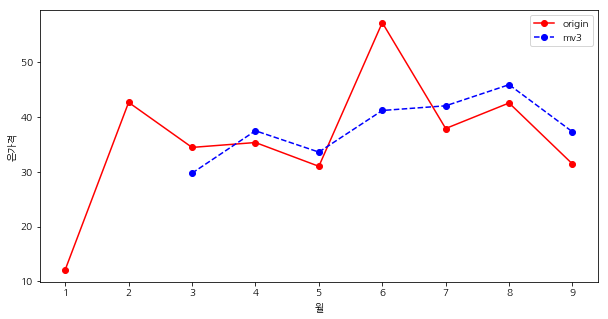

In [46]:
mv3 = df4.rolling(window=3).mean() #3이동평균

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(df4, marker='o', color='red', ls='-', label='origin')
ax.plot(mv3, marker='o', color='b', ls='--', label='mv3')
plt.legend()
ax.set_xlabel('월')
ax.set_ylabel('은가격')
plt.show()

원본데이터는 1월->2월에 4배 이상 상승했으며, 이후 평행선을 그리다 6월에 최고점을 기록했다. 이후 7월부터 약하락세를 보인다.  
이동평균 3은 점차적으로 증가 하였다가 약 하락세를 보이는 것을 알 수 있다. 

In [48]:
df4

,price
month,
1,12.14
2,42.60
3,34.40
4,35.29
5,30.96
6,57.12
7,37.84
8,42.49
9,31.38


2) **1월 대비 9월의 은의 가격은 몇 % 올랐는가? 소수점 두번째 자리에서 반올림**

In [62]:
jan = df4[df4.index == 1]['price'].values[0]
jun = df4[df4.index == 9]['price'].values[0]

ans = (jun - jan)/jan*100

print(f"1월 대비 9월의 은의 가격 상승률: {ans:.1f} %")

1월 대비 9월의 은의 가격 상승률: 158.5 %


## 문제 8

### height(키), weight(몸무게), waist(허리둘레) 컬럼을 가진 problem7.csv파일을 가지고 다음을 분석하라.
A시의 20대 남성 411명을 임의로 추출하여 키, 몸무게, 허리둘레를 조사하여 기록한 데이터이다.      
이 데이터를 이용하여 20대 남성의 키와 허리둘레가 체중에 영향을 미치는지 알아보고자 한다

In [63]:
df = pd.read_csv('https://raw.githubusercontent.com/TKV-JONGIN/DataSet/refs/heads/main/ADP_26_problem7.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411 entries, 0 to 410
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   height     411 non-null    float64
 1   weight     411 non-null    float64
 2   waistline  411 non-null    float64
dtypes: float64(3)
memory usage: 9.8 KB


,height,weight,waistline
0,174.396,72.102,79.3787
1,179.656,81.255,80.6649
2,175.079,76.207,80.3166
3,180.804,81.354,80.8794
4,177.448,78.768,80.3499


1) **아래 조건을 참고하여 회귀계수(반올림하여 소수점 두자리)를 구하시오.**
- 베이지안 회귀
- 시드넘버 1234로 지정
- 1000번의 burn-in 이후 10,000의 MCMC를 수행
- 회귀계수의 사전분포는 부적절한 균일분포(inproper uniform prior distribution), 오차항의 분산의 사전분포는 역감마 분포로 지정. 이때, 형상(Shape)모수와 척도(Scale)모수는 각각 0.005로 지정.

In [67]:
# MCMC는 지정불가
from sklearn.linear_model import BayesianRidge

x = df.drop('weight', axis=1)
y = df['weight']

br = BayesianRidge(n_iter=1000, 
                  fit_intercept=True, alpha_1 = 0.005, alpha_2=0.005)

br.fit(x, y)

BayesianRidge(alpha_1=0.005, alpha_2=0.005, n_iter=1000)

라이브러리 자원이 안되서 시드넘버와 MCMC는 지정할 수 없었다.  
나머지 조건을 반영하여 모델을 만들었다. 

2) **위1)에서 만든 모델을 바탕으로 키 180cm, 허리둘레 85cm인 남성의 몸무게를 추정하라**

In [74]:
pred = br.predict([[180, 85]])

print(f"키 180cm, 허리둘레 85cm인 남성의 몸무게 예측: {pred}")

키 180cm, 허리둘레 85cm인 남성의 몸무게 예측: [81.00211341]
